In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# Define data directory
data_dir = Path('agent_0')

# Load all CSV files
action_df = pd.read_csv(data_dir / 'action.csv')
allocation_df = pd.read_csv(data_dir / 'allocation.csv')
energy_df = pd.read_csv(data_dir / 'energy.csv', header=None, names=['energy'])
latency_df = pd.read_csv(data_dir / 'latency.csv', header=None, names=['latency'])
rejection_df = pd.read_csv(data_dir / 'rejection.csv')
reward_df = pd.read_csv(data_dir / 'reward.csv', header=None, names=['reward'])

print("Data loaded successfully!")
print(f"Number of episodes: {len(reward_df)}")
print(f"Action columns: {list(action_df.columns)}")
print(f"Allocation columns: {list(allocation_df.columns)}")
print(f"Rejection columns: {list(rejection_df.columns)}")

Data loaded successfully!
Number of episodes: 499713
Action columns: ['mec_0', 'mec_1', 'mec_2', 'mec_3', 'mec_4', 'link_0', 'link_1', 'link_2', 'link_3', 'link_4', 'link_5', 'link_6', 'link_7', 'link_8', 'link_9']
Allocation columns: ['mec_0', 'mec_1', 'mec_2', 'mec_3', 'mec_4', 'link_0', 'link_1', 'link_2', 'link_3', 'link_4', 'link_5', 'link_6', 'link_7', 'link_8', 'link_9']
Rejection columns: ['mec_0', 'mec_1', 'mec_2', 'mec_3', 'mec_4', 'link_0', 'link_1', 'link_2', 'link_3', 'link_4', 'link_5', 'link_6', 'link_7', 'link_8', 'link_9']


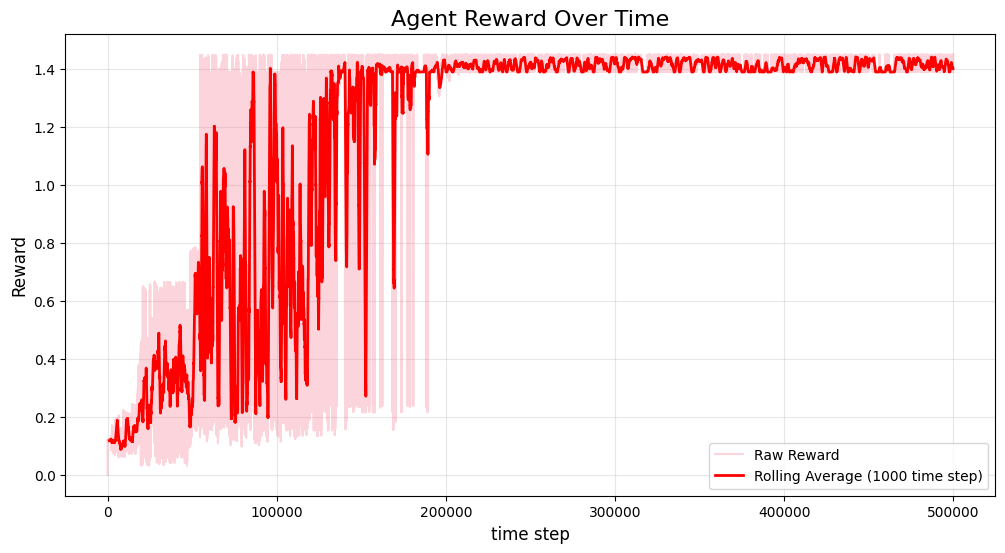

Mean reward: 1.1703
Std reward: 0.4742
Min reward: 0.0000
Max reward: 1.4504
Rolling average (last 1000): 1.4029


In [20]:
# Cell 2: Plot reward over time
plt.figure(figsize=(12, 6))
plt.plot(reward_df.index, reward_df['reward'], alpha=0.3, label='Raw Reward')
reward_rolling = reward_df['reward'].rolling(window=1000).mean()
plt.plot(reward_df.index, reward_rolling, linewidth=2, label='Rolling Average (1000 time step)', color='red')
plt.title('Agent Reward Over Time', fontsize=16)
plt.xlabel('time step', fontsize=12)
plt.ylabel('Reward', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Calculate and display reward statistics
print(f"Mean reward: {reward_df['reward'].mean():.4f}")
print(f"Std reward: {reward_df['reward'].std():.4f}")
print(f"Min reward: {reward_df['reward'].min():.4f}")
print(f"Max reward: {reward_df['reward'].max():.4f}")
print(f"Rolling average (last 1000): {reward_rolling.iloc[-1]:.4f}")

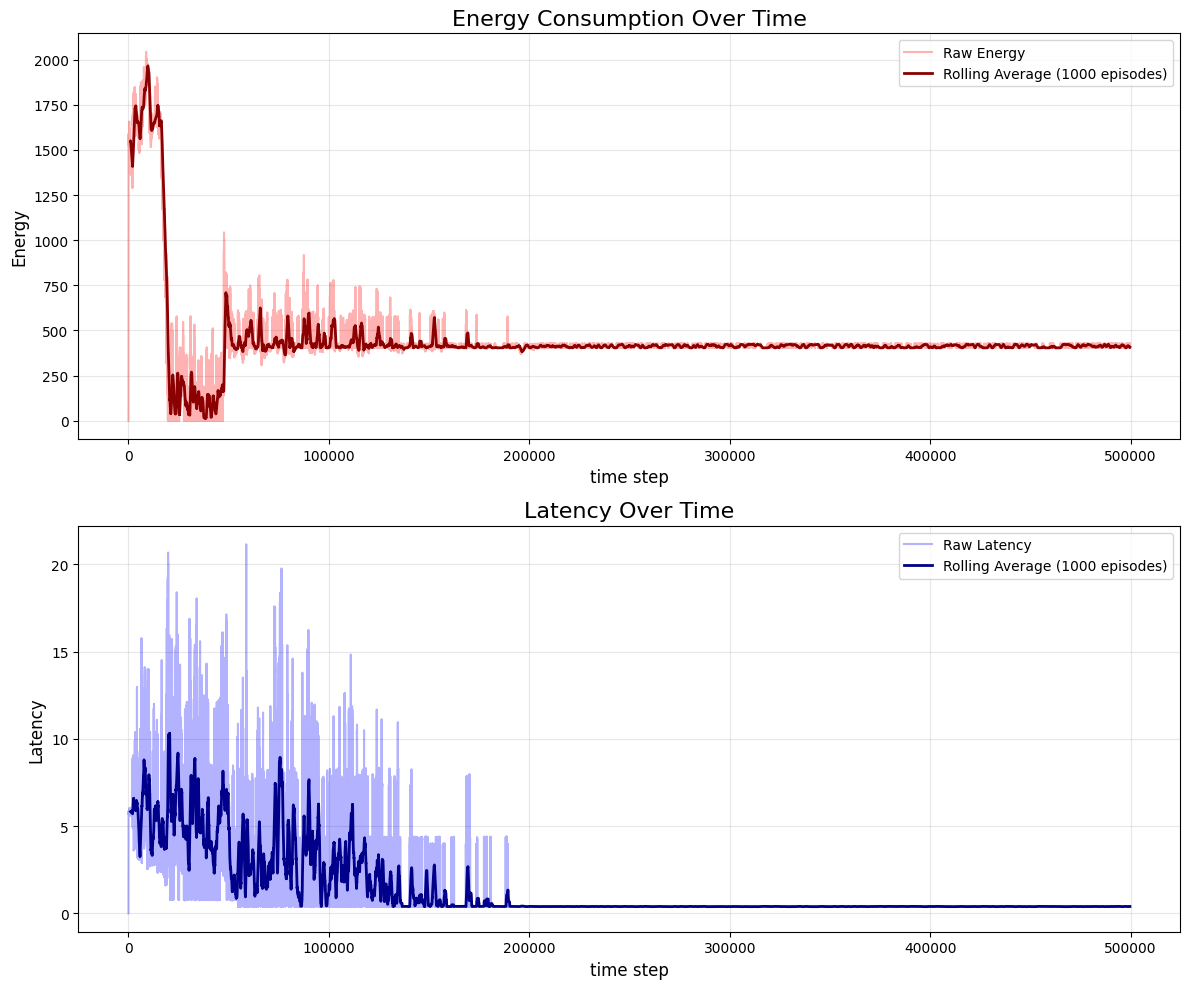

Energy Statistics:
Mean: 447.48, Std: 249.51
Min: 0.00, Max: 2043.51
Rolling average (last 1000): 408.43

Latency Statistics:
Mean: 1.36, Std: 2.26
Min: 0.00, Max: 21.15
Rolling average (last 1000): 0.39


In [21]:
# Cell 3: Plot energy and latency over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Energy plot
ax1.plot(energy_df.index, energy_df['energy'], alpha=0.3, color='red', label='Raw Energy')
energy_rolling = energy_df['energy'].rolling(window=1000).mean()
ax1.plot(energy_df.index, energy_rolling, linewidth=2, label='Rolling Average (1000 episodes)', color='darkred')
ax1.set_title('Energy Consumption Over Time', fontsize=16)
ax1.set_xlabel('time step', fontsize=12)
ax1.set_ylabel('Energy', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Latency plot
ax2.plot(latency_df.index, latency_df['latency'], alpha=0.3, color='blue', label='Raw Latency')
latency_rolling = latency_df['latency'].rolling(window=1000).mean()
ax2.plot(latency_df.index, latency_rolling, linewidth=2, label='Rolling Average (1000 episodes)', color='darkblue')
ax2.set_title('Latency Over Time', fontsize=16)
ax2.set_xlabel('time step', fontsize=12)
ax2.set_ylabel('Latency', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics
print("Energy Statistics:")
print(f"Mean: {energy_df['energy'].mean():.2f}, Std: {energy_df['energy'].std():.2f}")
print(f"Min: {energy_df['energy'].min():.2f}, Max: {energy_df['energy'].max():.2f}")
print(f"Rolling average (last 1000): {energy_rolling.iloc[-1]:.2f}")

print("\nLatency Statistics:")
print(f"Mean: {latency_df['latency'].mean():.2f}, Std: {latency_df['latency'].std():.2f}")
print(f"Min: {latency_df['latency'].min():.2f}, Max: {latency_df['latency'].max():.2f}")
print(f"Rolling average (last 1000): {latency_rolling.iloc[-1]:.2f}")

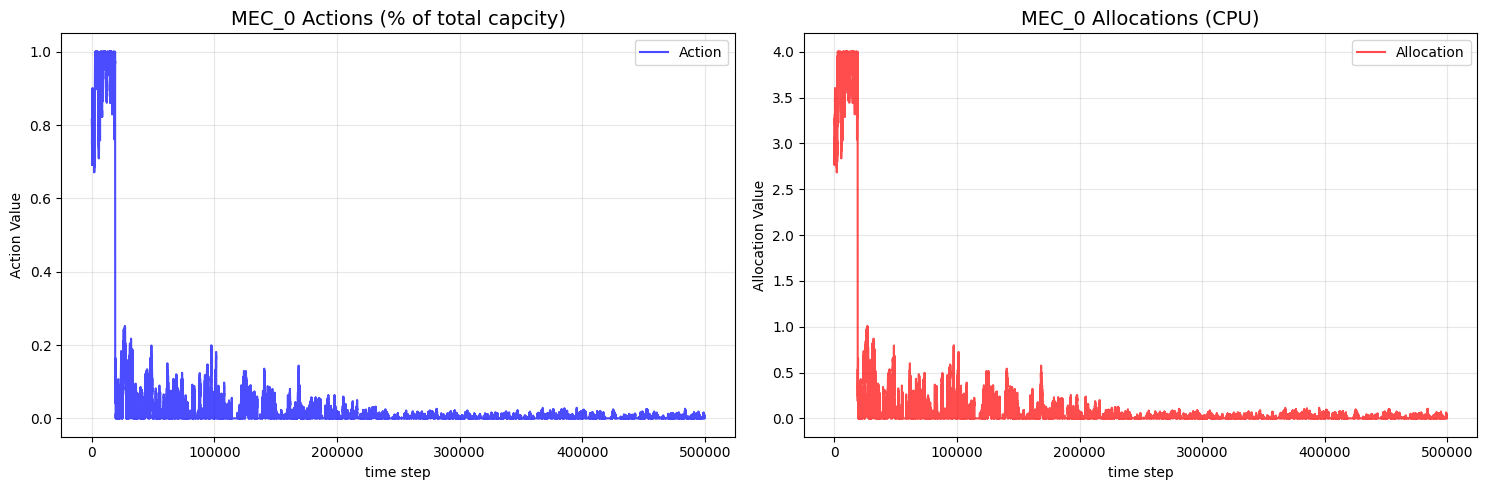

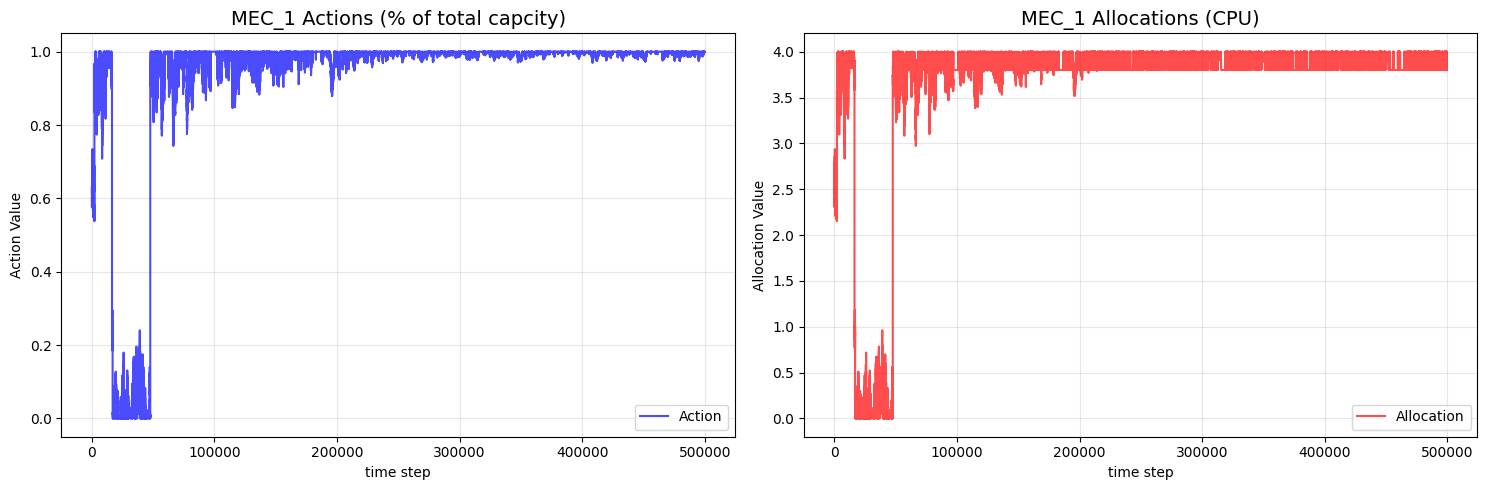

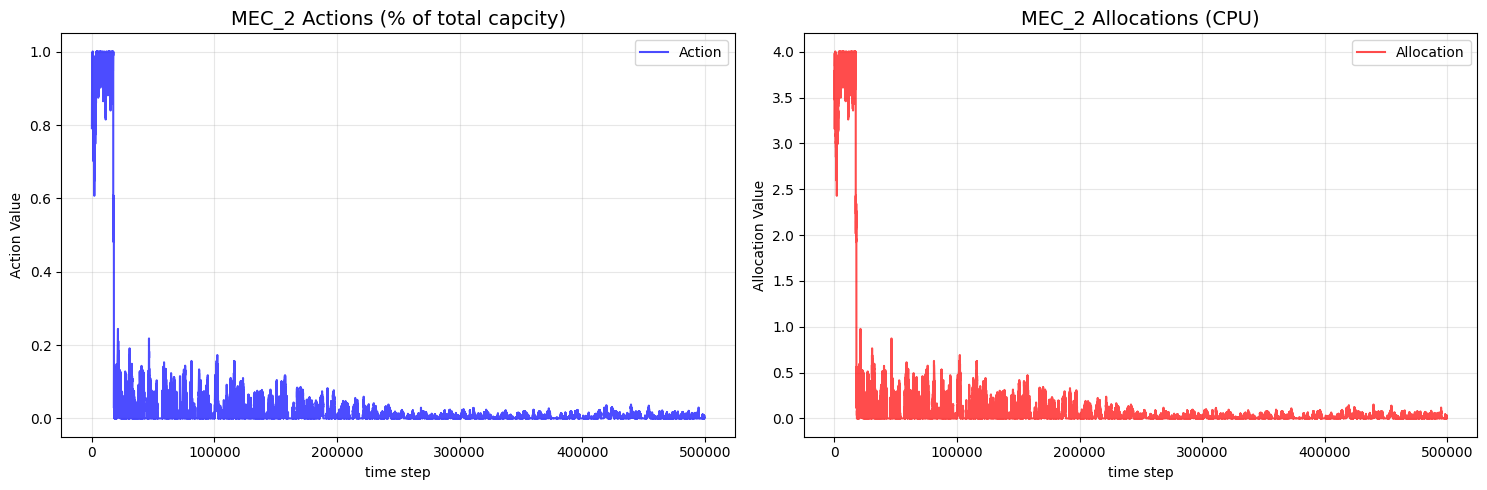

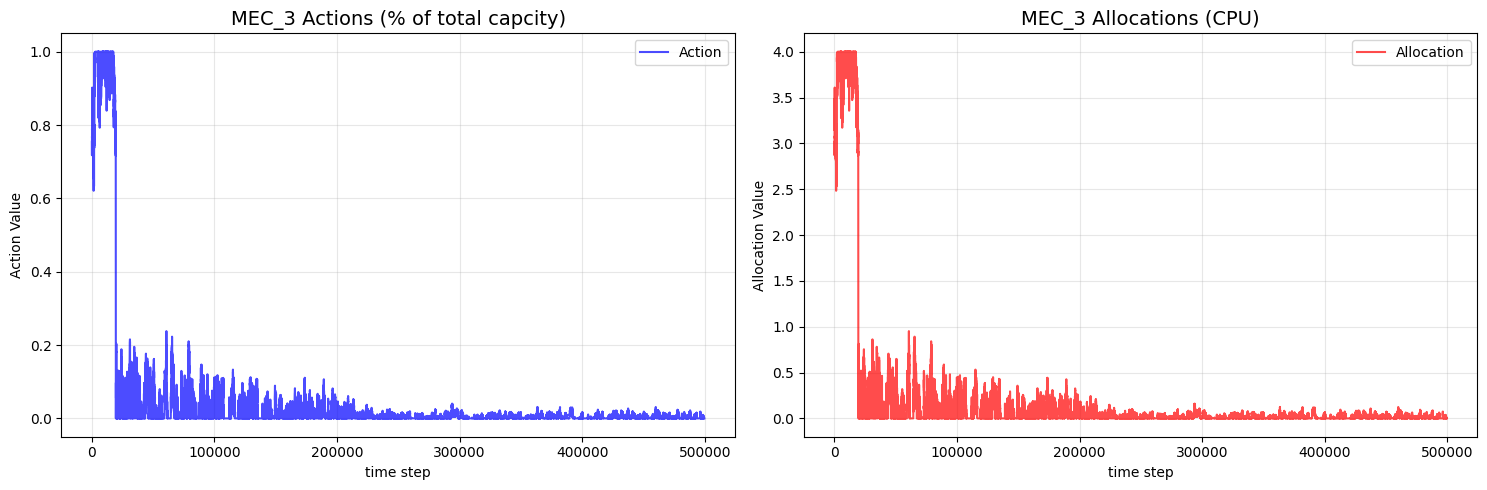

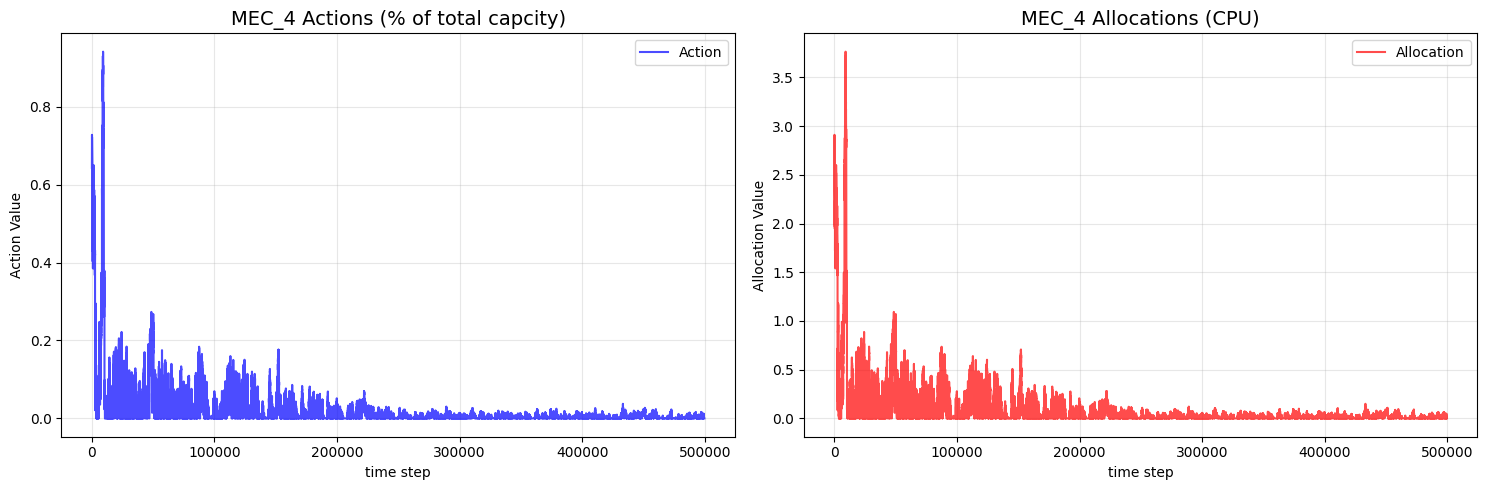

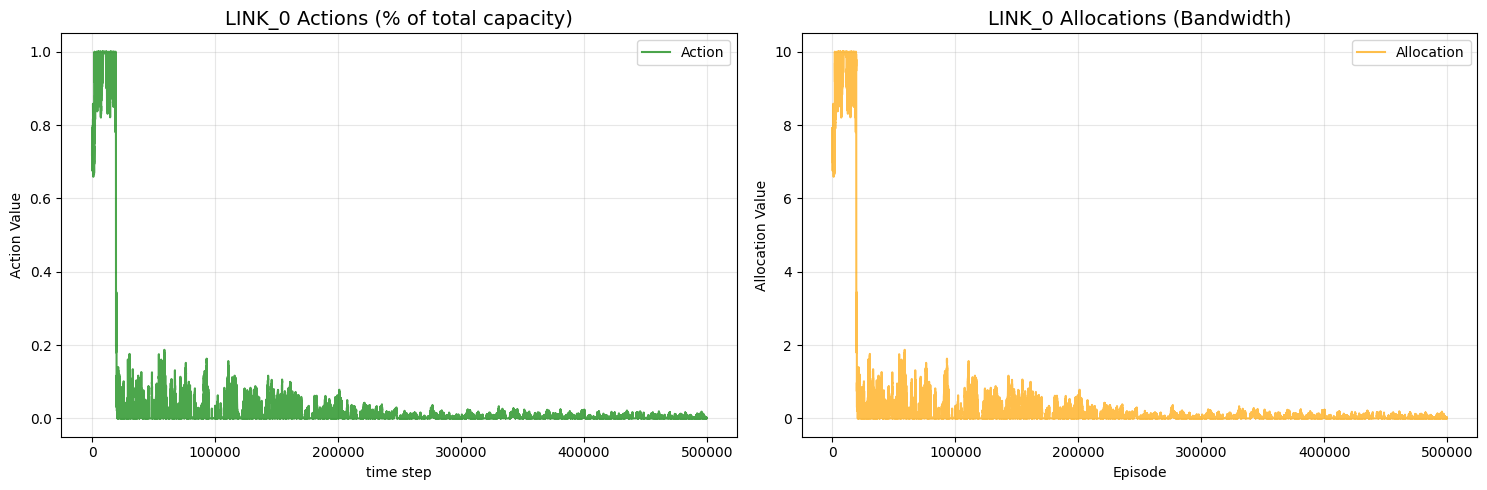

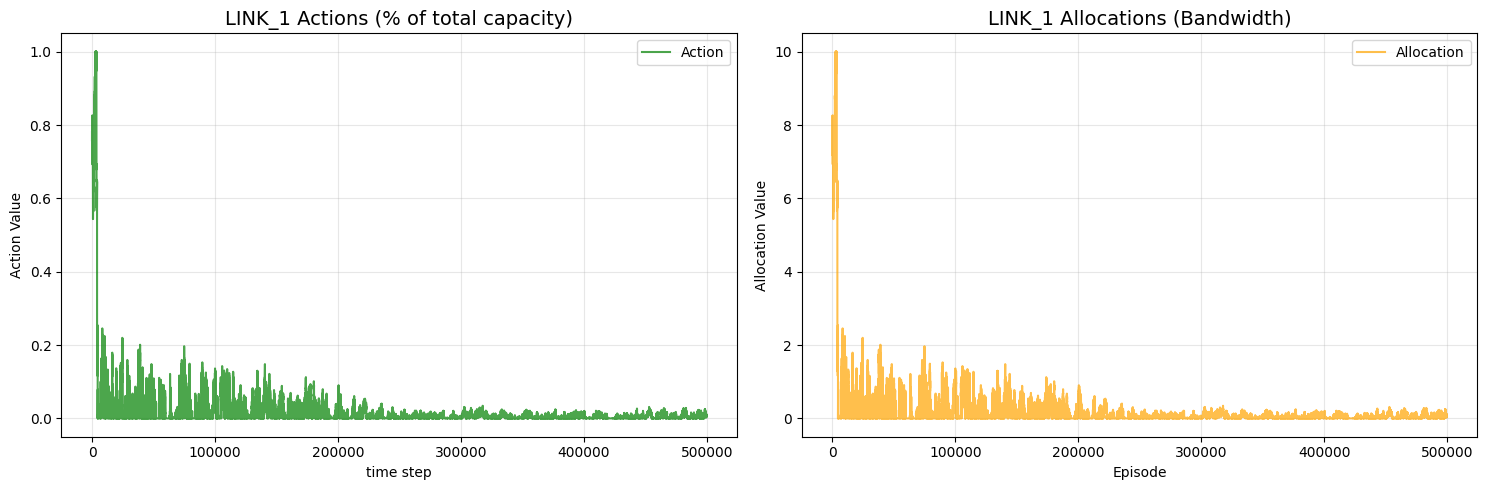

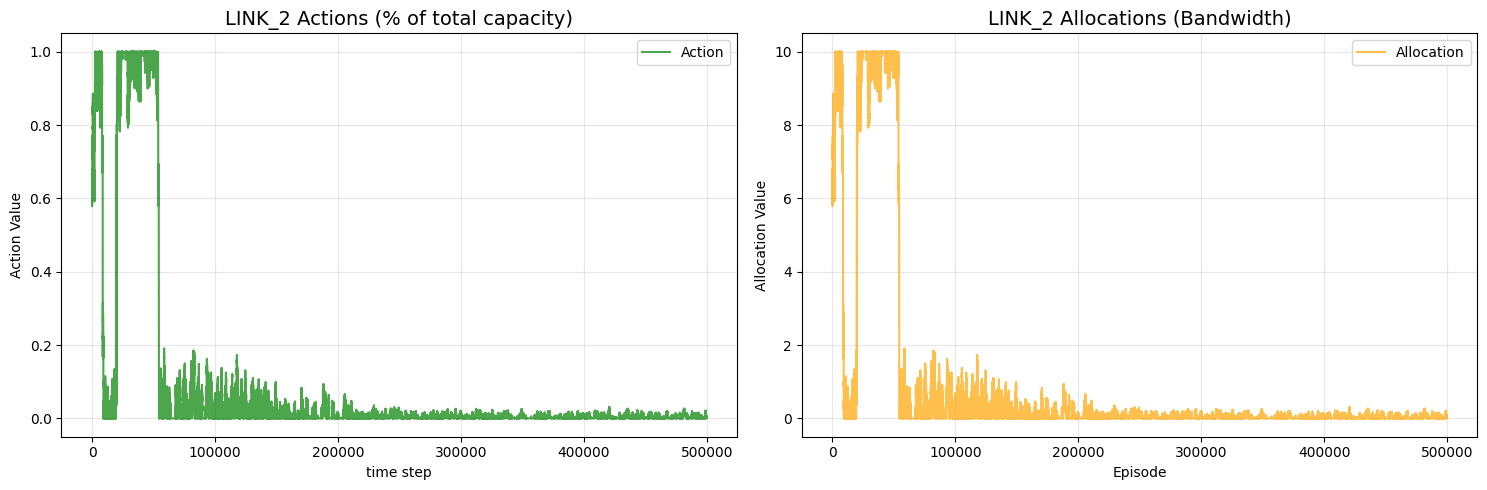

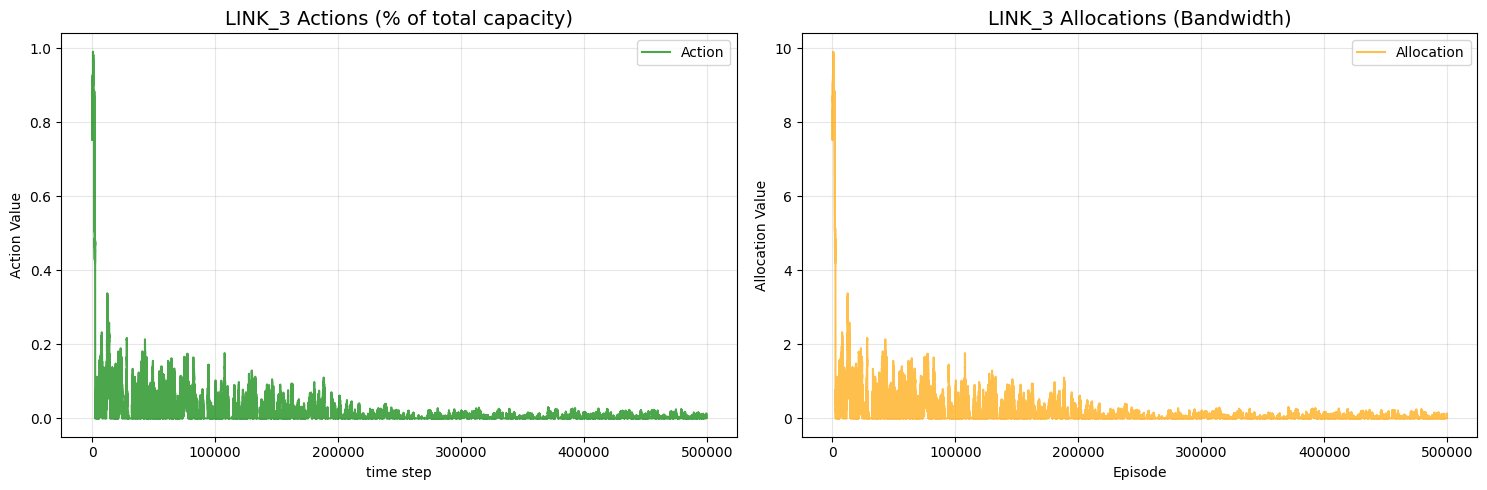

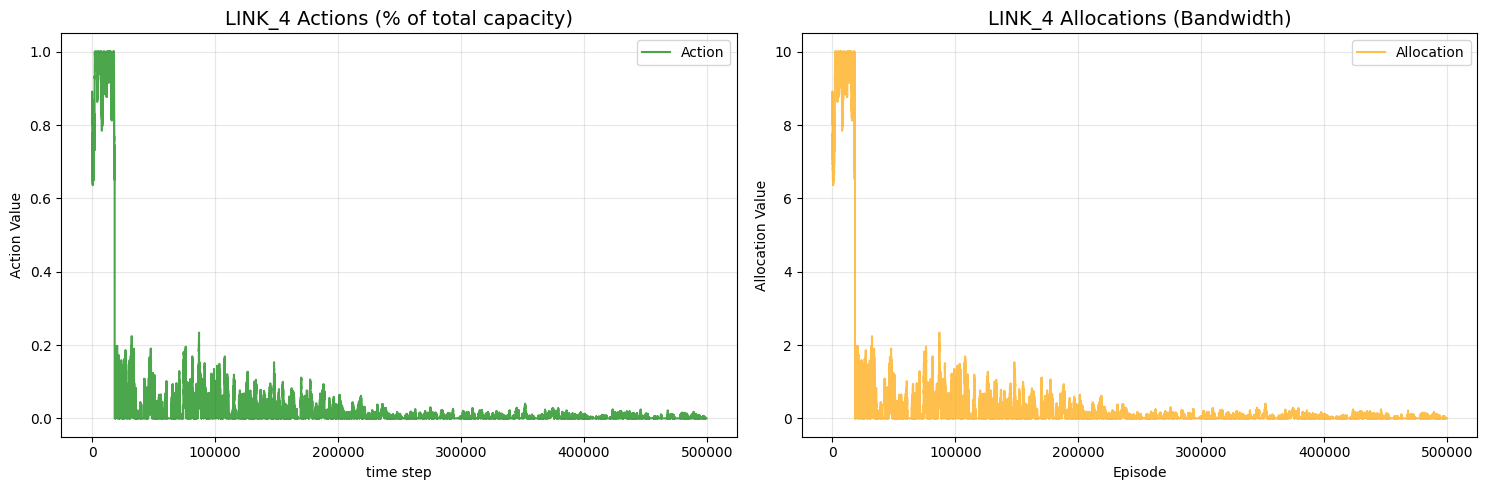

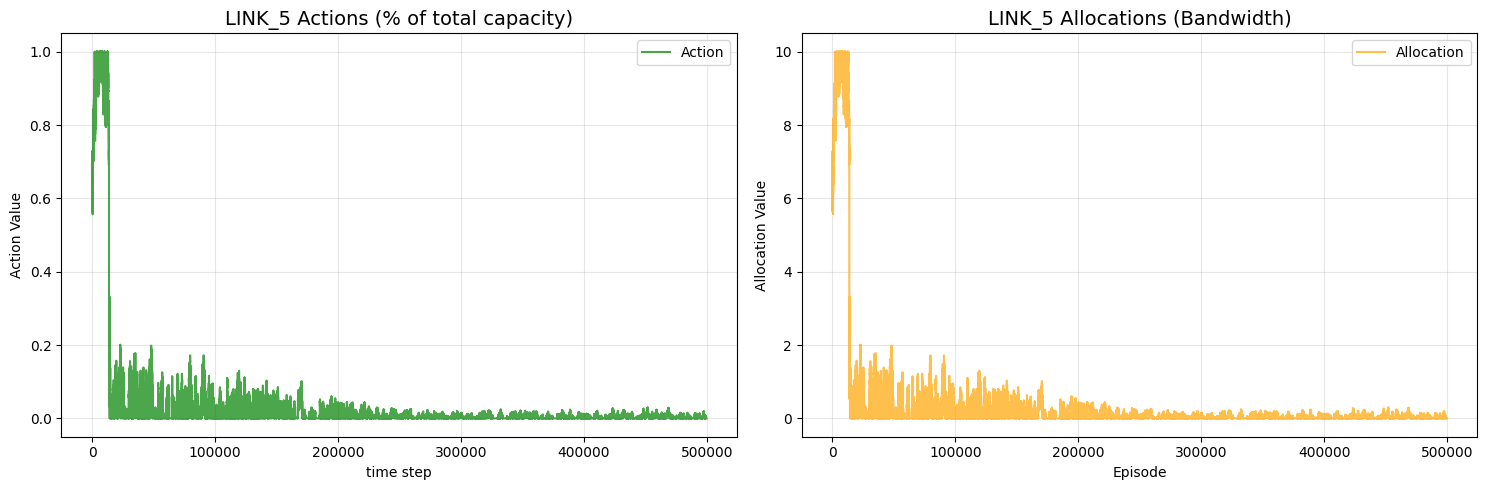

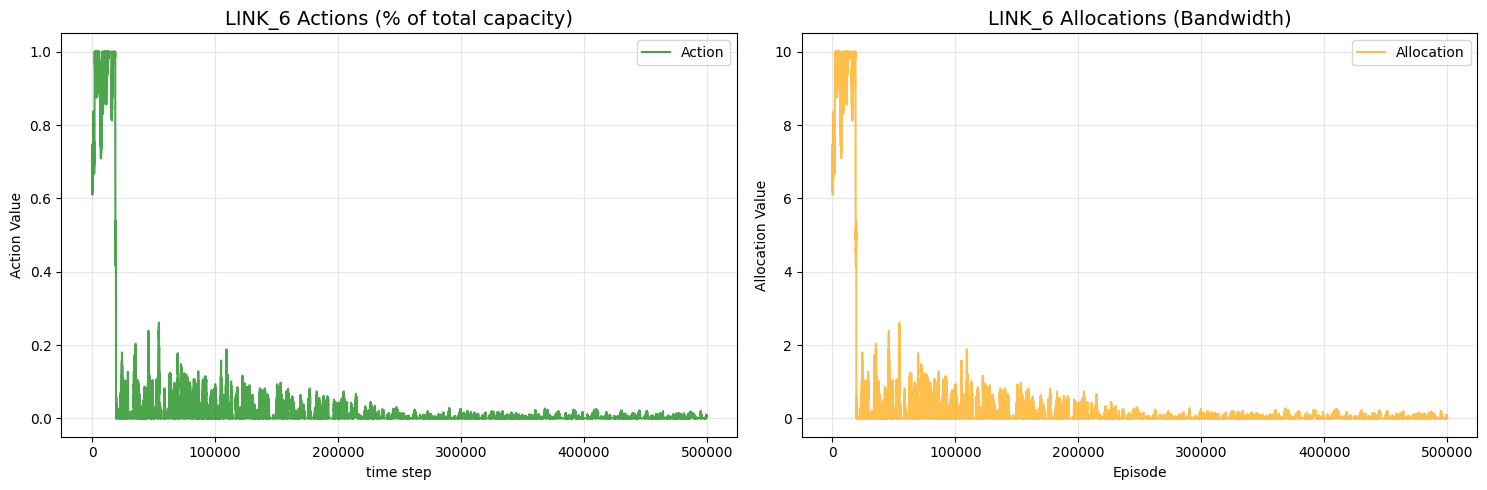

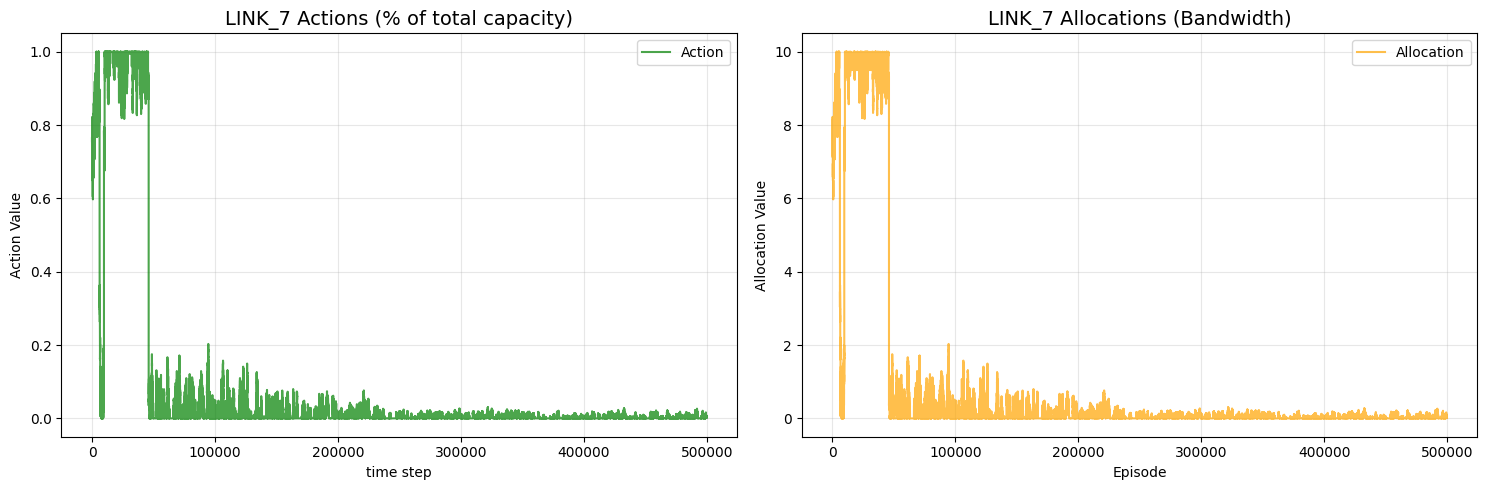

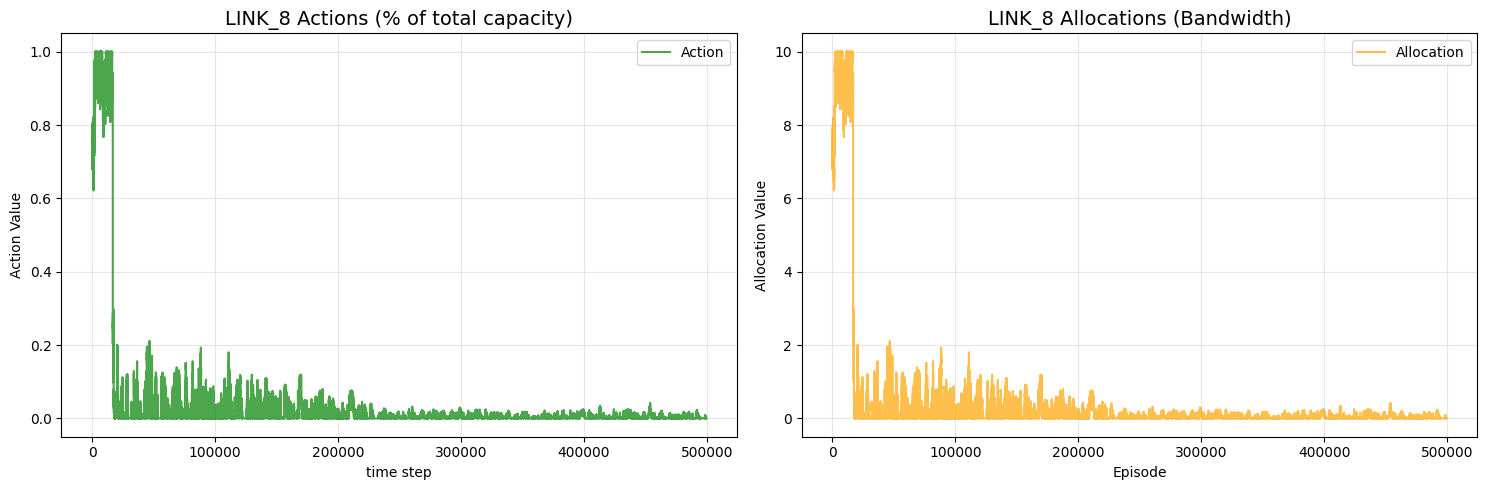

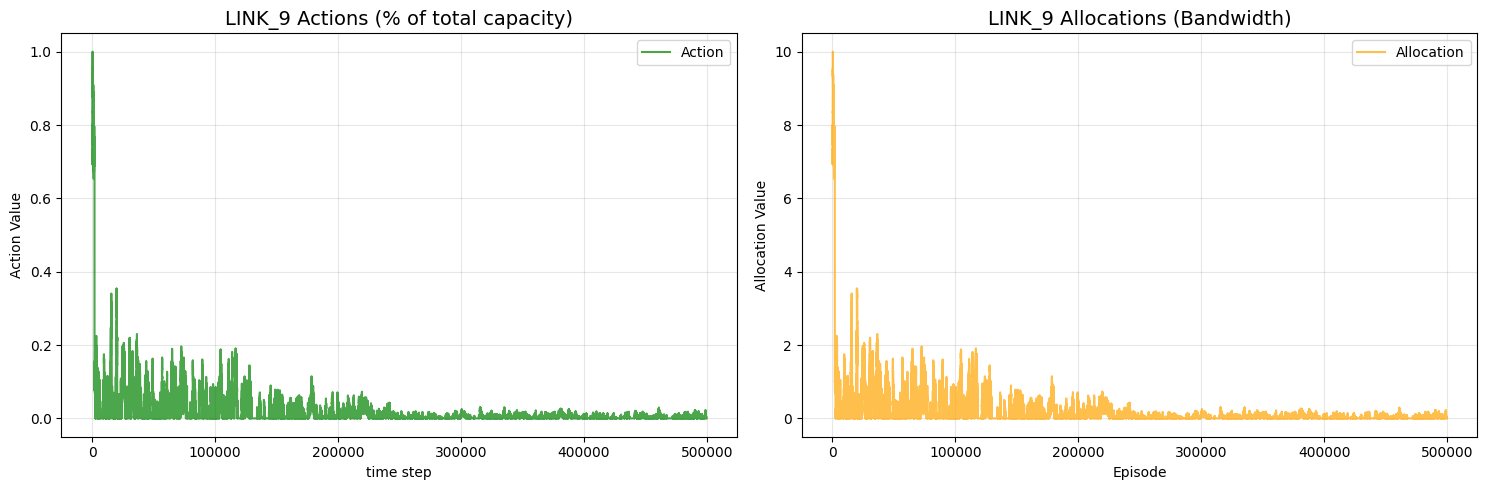

In [22]:
# Cell 4: Individual plots for each MEC and Link resource
sample_size = min(500000, len(action_df))  # Show more episodes for better trend visibility

# Plot MEC resources
mec_cols = [col for col in action_df.columns if col.startswith('mec_')]
for i, mec in enumerate(mec_cols):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Actions
    ax1.plot(action_df.index[:sample_size], action_df[mec][:sample_size], alpha=0.7, color='blue', label='Action')
    ax1.set_title(f'{mec.upper()} Actions (% of total capcity)', fontsize=14)
    ax1.set_xlabel('time step')
    ax1.set_ylabel('Action Value')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Allocations
    ax2.plot(allocation_df.index[:sample_size], allocation_df[mec][:sample_size], alpha=0.7, color='red', label='Allocation')
    ax2.set_title(f'{mec.upper()} Allocations (CPU)', fontsize=14)
    ax2.set_xlabel('time step')
    ax2.set_ylabel('Allocation Value')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()

# Plot Link resources
link_cols = [col for col in action_df.columns if col.startswith('link_')]
for i, link in enumerate(link_cols):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Actions
    ax1.plot(action_df.index[:sample_size], action_df[link][:sample_size], alpha=0.7, color='green', label='Action')
    ax1.set_title(f'{link.upper()} Actions (% of total capacity)', fontsize=14)
    ax1.set_xlabel('time step')
    ax1.set_ylabel('Action Value')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Allocations
    ax2.plot(allocation_df.index[:sample_size], allocation_df[link][:sample_size], alpha=0.7, color='orange', label='Allocation')
    ax2.set_title(f'{link.upper()} Allocations (Bandwidth)', fontsize=14)
    ax2.set_xlabel('Episode')
    ax2.set_ylabel('Allocation Value')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()

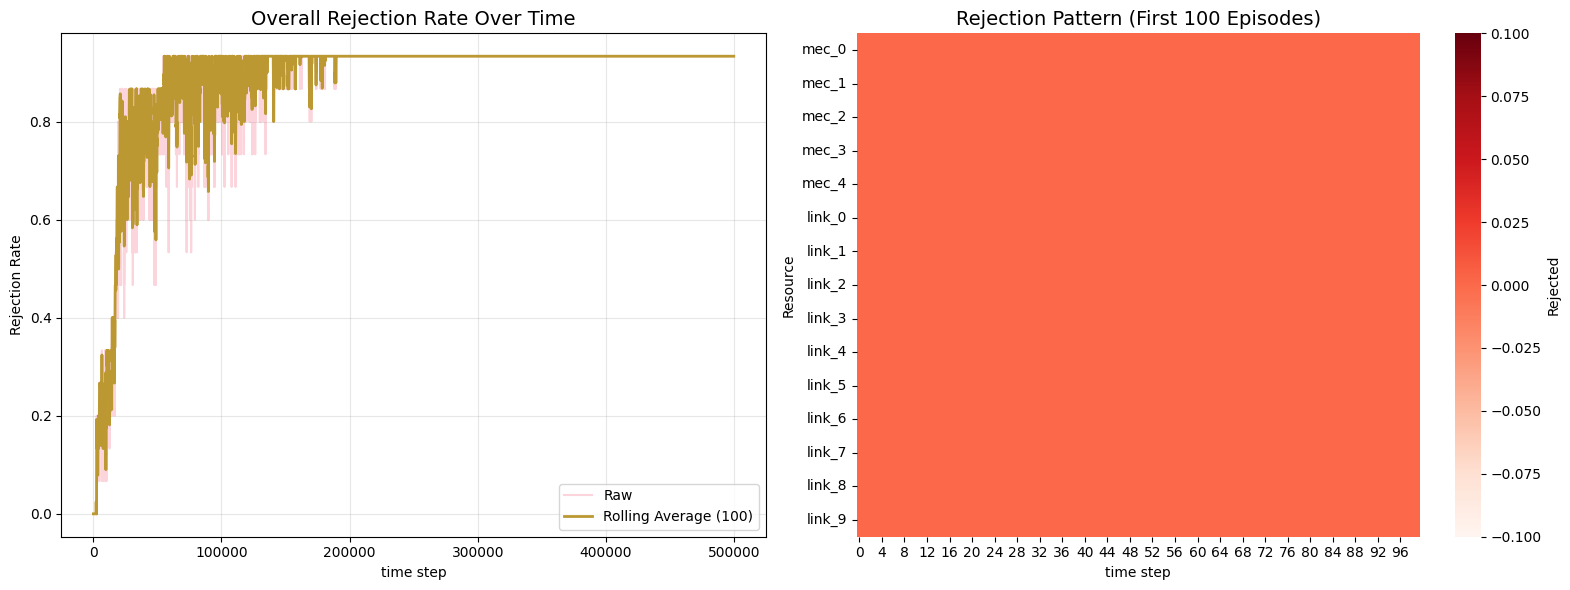

Rejection Statistics:
Overall rejection rate: 0.885
MEC rejection rates: 0.768
Link rejection rates: 0.944

MEC Rejection Rates by Resource:
mec_0: 0.941
mec_1: 0.055
mec_2: 0.949
mec_3: 0.940
mec_4: 0.955

Link Rejection Rates by Resource:
link_0: 0.950
link_1: 0.970
link_2: 0.900
link_3: 0.964
link_4: 0.937
link_5: 0.955
link_6: 0.950
link_7: 0.903
link_8: 0.953
link_9: 0.960


In [23]:
# Cell 5: Rejection analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Rejection rates over time (rolling average)
rejection_df = 1 - rejection_df
rejection_rate = rejection_df.mean(axis=1)
rejection_rate_rolling = rejection_rate.rolling(window=100).mean()

ax1.plot(rejection_df.index, rejection_rate, alpha=0.3, label='Raw')
ax1.plot(rejection_df.index, rejection_rate_rolling, label='Rolling Average (100)', linewidth=2)
ax1.set_title('Overall Rejection Rate Over Time', fontsize=14)
ax1.set_xlabel('time step')
ax1.set_ylabel('Rejection Rate')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Rejection heatmap for first 100 episodes
rejection_sample = rejection_df.head(100)
sns.heatmap(rejection_sample.T, ax=ax2, cmap='Reds', cbar_kws={'label': 'Rejected'})
ax2.set_title('Rejection Pattern (First 100 Episodes)', fontsize=14)
ax2.set_xlabel('time step')
ax2.set_ylabel('Resource')

plt.tight_layout()
plt.show()

# Rejection statistics by resource type
mec_rejections = rejection_df[[col for col in rejection_df.columns if col.startswith('mec_')]].mean()
link_rejections = rejection_df[[col for col in rejection_df.columns if col.startswith('link_')]].mean()

print("Rejection Statistics:")
print(f"Overall rejection rate: {rejection_rate.mean():.3f}")
print(f"MEC rejection rates: {mec_rejections.mean():.3f}")
print(f"Link rejection rates: {link_rejections.mean():.3f}")

print("\nMEC Rejection Rates by Resource:")
for col, rate in mec_rejections.items():
    print(f"{col}: {rate:.3f}")

print("\nLink Rejection Rates by Resource:")
for col, rate in link_rejections.items():
    print(f"{col}: {rate:.3f}")

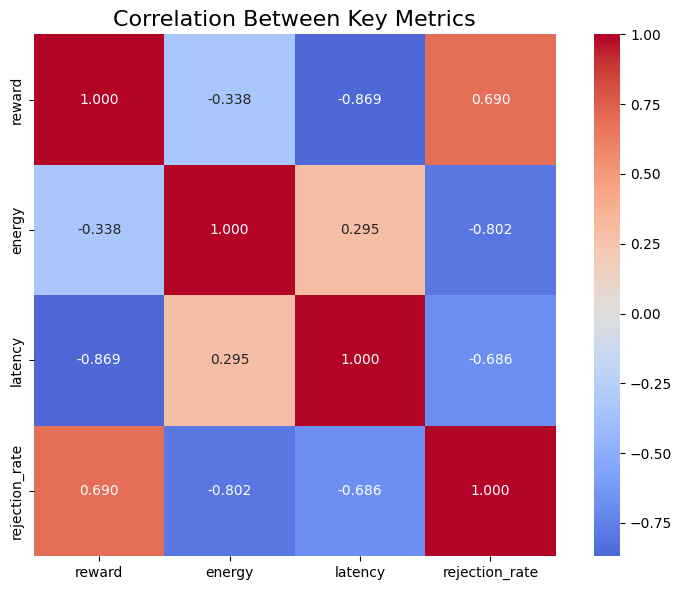

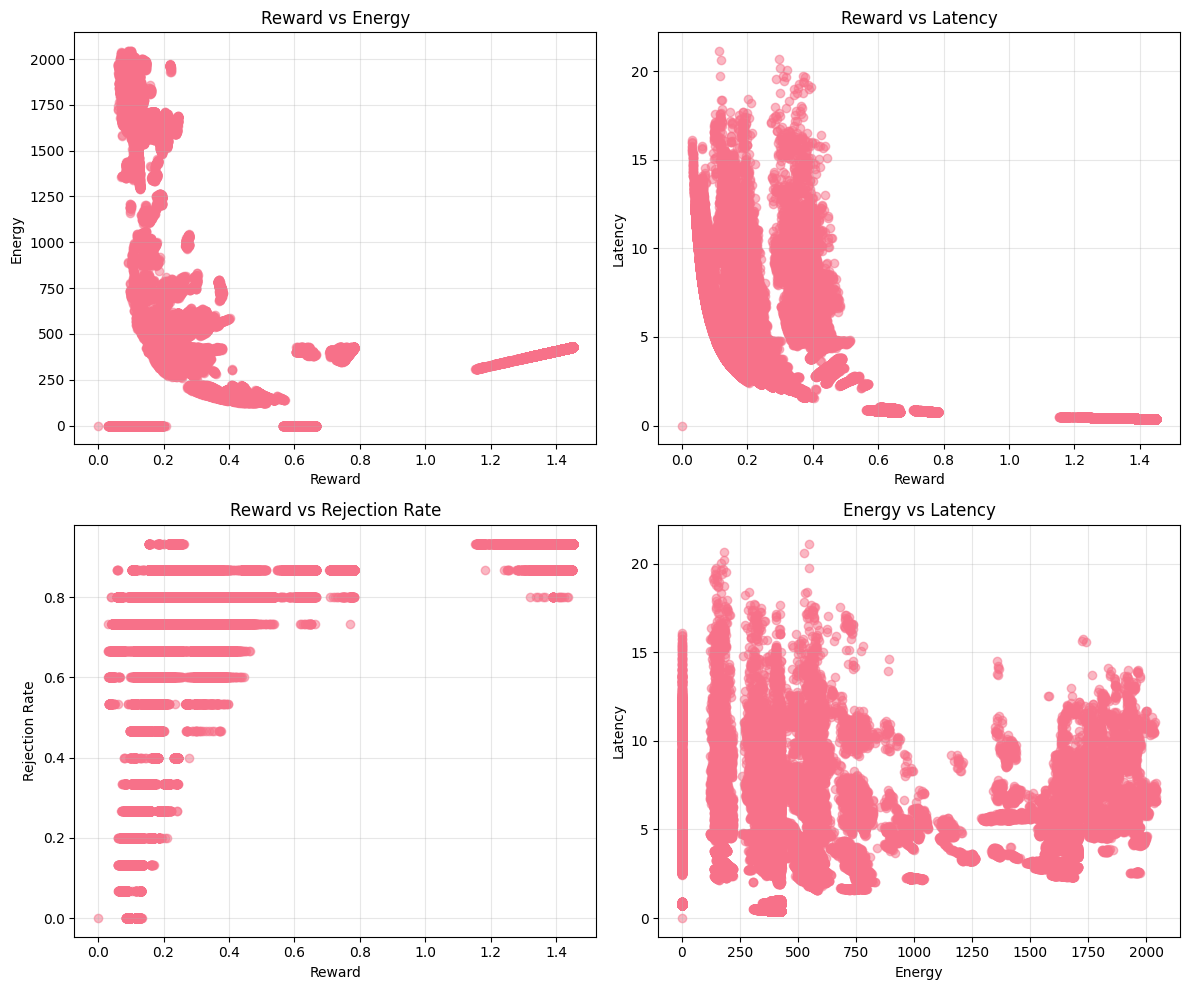

Correlation Matrix:
                  reward    energy   latency  rejection_rate
reward          1.000000 -0.337654 -0.869120        0.690289
energy         -0.337654  1.000000  0.294814       -0.802367
latency        -0.869120  0.294814  1.000000       -0.686047
rejection_rate  0.690289 -0.802367 -0.686047        1.000000


In [24]:
# Cell 6: Correlation analysis
# Combine all metrics into one dataframe for correlation analysis
combined_df = pd.DataFrame({
    'reward': reward_df['reward'],
    'energy': energy_df['energy'],
    'latency': latency_df['latency'],
    'rejection_rate': rejection_df.mean(axis=1)
})

# Calculate correlations
correlation_matrix = combined_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f', square=True)
plt.title('Correlation Between Key Metrics', fontsize=16)
plt.tight_layout()
plt.show()

# Plot relationships between key metrics
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Reward vs Energy
axes[0,0].scatter(combined_df['reward'], combined_df['energy'], alpha=0.5)
axes[0,0].set_xlabel('Reward')
axes[0,0].set_ylabel('Energy')
axes[0,0].set_title('Reward vs Energy')
axes[0,0].grid(True, alpha=0.3)

# Reward vs Latency
axes[0,1].scatter(combined_df['reward'], combined_df['latency'], alpha=0.5)
axes[0,1].set_xlabel('Reward')
axes[0,1].set_ylabel('Latency')
axes[0,1].set_title('Reward vs Latency')
axes[0,1].grid(True, alpha=0.3)

# Reward vs Rejection Rate
axes[1,0].scatter(combined_df['reward'], combined_df['rejection_rate'], alpha=0.5)
axes[1,0].set_xlabel('Reward')
axes[1,0].set_ylabel('Rejection Rate')
axes[1,0].set_title('Reward vs Rejection Rate')
axes[1,0].grid(True, alpha=0.3)

# Energy vs Latency
axes[1,1].scatter(combined_df['energy'], combined_df['latency'], alpha=0.5)
axes[1,1].set_xlabel('Energy')
axes[1,1].set_ylabel('Latency')
axes[1,1].set_title('Energy vs Latency')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Correlation Matrix:")
print(correlation_matrix)